# **Import Library**

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn


from torchvision import datasets, transforms
from torch.utils.data import DataLoader


from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Pipeline Configuration

In [3]:
# ====================================================
# CONFIGURATION eksperimen 4
# ====================================================

SEED = 42
BATCH_SIZE = 32
EPOCHS = 20

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
BEST_DROPOUT = 0.2


DATA_DIR = "/kaggle/input/datasets/christozwingly/daisee-v2/Output_Faces_ViT_224"

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR   = os.path.join(DATA_DIR, "validation")
TEST_DIR  = os.path.join(DATA_DIR, "test")

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device :", device)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device : cuda


# Data Visual


[Subset: train]
 Label 0: 1480 gambar
 Label 1: 52087 gambar
 Total: 53567 gambar

[Subset: validation]
 Label 0: 1037 gambar
 Label 1: 13249 gambar
 Total: 14286 gambar

[Subset: test]
 Label 0: 520 gambar
 Label 1: 17313 gambar
 Total: 17833 gambar


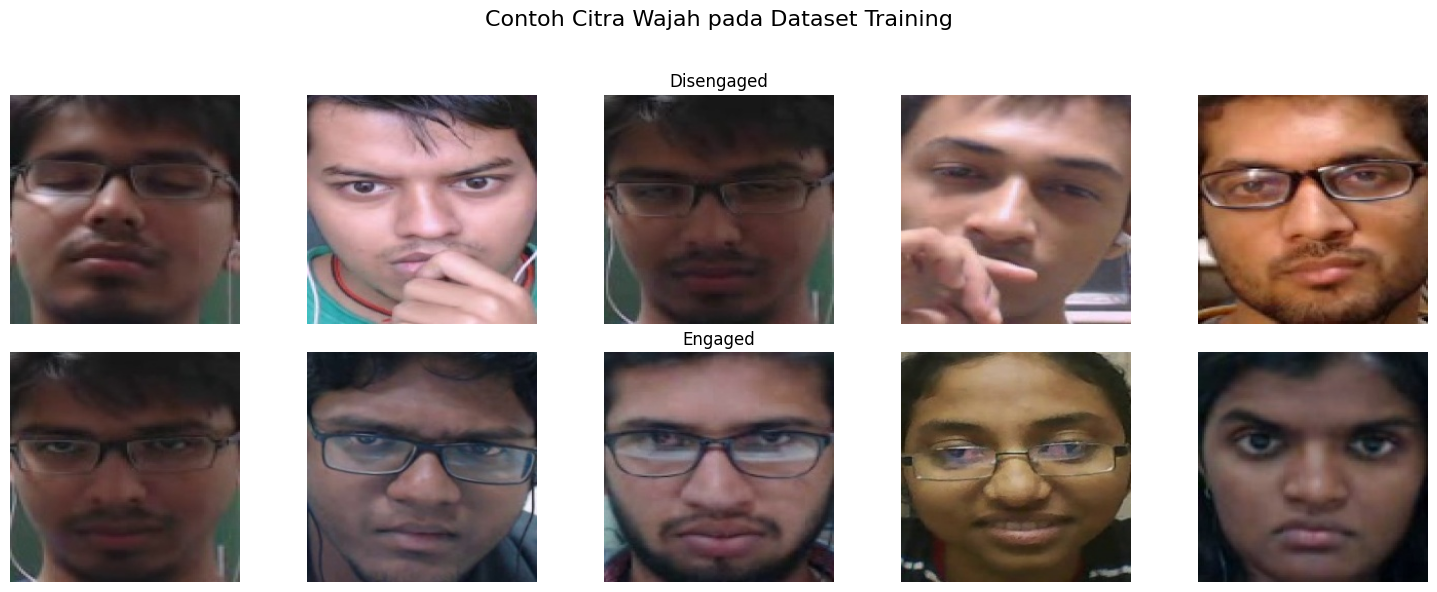

In [4]:
import matplotlib.image as mpimg

# ----------------------------------------------------
# DISTRIBUSI DATASET
# ----------------------------------------------------

for split in ['train', 'validation', 'test']:
    total = 0
    print(f"\n[Subset: {split}]")

    for label in ['0', '1']:
        dir_path = os.path.join(
            DATA_DIR,
            split,
            label
        )

        if os.path.exists(dir_path):
            count = len(
                os.listdir(dir_path)
            )
            print(
                f" Label {label}: {count} gambar"
            )
            total += count
        else:
            print(
                f" Direktori tidak ditemukan: {dir_path}"
            )
    print(f" Total: {total} gambar")


# ----------------------------------------------------
# CONTOH CITRA TRAINING
# ----------------------------------------------------

dataset_path = os.path.join(
    DATA_DIR,
    'train'
)
labels = {
    '0': 'Disengaged',
    '1': 'Engaged'
}
fig, axes = plt.subplots(2,5,
    figsize=(15,6)
)
fig.suptitle(
    "Contoh Citra Wajah pada Dataset Training",
    fontsize=16
)
for i, label in enumerate(['0', '1']):

    class_dir = os.path.join(
        dataset_path,
        label
    )
    all_images = os.listdir(
        class_dir
    )
    sample_images = random.sample(
        all_images,
        min(5, len(all_images))
    )
    for j, img_name in enumerate(
        sample_images
    ):
        img_path = os.path.join(
            class_dir,
            img_name
        )
        img = mpimg.imread(
            img_path
        )
        ax = axes[i][j]
        ax.imshow(img)
        ax.axis('off')

        if j == 2:
            ax.set_title(
                labels[label],
                fontsize=12
            )
plt.tight_layout(
    rect=[0,0,1,0.95]
)
plt.show()

# Prepare Data 

In [5]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

# Model Architecture (Vision Transformer) 

In [6]:
import timm


model = timm.create_model(
    "vit_small_patch16_224.augreg_in21k_ft_in1k",
    pretrained=True,
    num_classes=2,
    drop_rate=BEST_DROPOUT
)

print(model.pretrained_cfg)

from timm.data import resolve_model_data_config

print(resolve_model_data_config(model))

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2225: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

{'url': 'https://storage.googleapis.com/vit_models/augreg/S_16-i21k-300ep-lr_0.001-aug_light1-wd_0.03-do_0.0-sd_0.0--imagenet2012-steps_20k-lr_0.03-res_224.npz', 'hf_hub_id': 'timm/vit_small_patch16_224.augreg_in21k_ft_in1k', 'architecture': 'vit_small_patch16_224', 'tag': 'augreg_in21k_ft_in1k', 'custom_load': True, 'input_size': (3, 224, 224), 'fixed_input_size': True, 'interpolation': 'bicubic', 'crop_pct': 0.9, 'crop_mode': 'center', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'num_classes': 1000, 'pool_size': None, 'first_conv': 'patch_embed.proj', 'classifier': 'head'}
{'input_size': (3, 224, 224), 'interpolation': 'bicubic', 'mean': (0.5, 0.5, 0.5), 'std': (0.5, 0.5, 0.5), 'crop_pct': 0.9, 'crop_mode': 'center'}


In [7]:
model = timm.create_model(
    "vit_small_patch16_224.augreg_in21k_ft_in1k",
    pretrained=True,
    num_classes=2,
    drop_rate=BEST_DROPOUT
)
model = model.to(device)

print(model)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False

# Prepare Dataset

In [8]:
train_dataset = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=val_test_transform
)

print("Train      :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test       :", len(test_dataset))

Train      : 53567
Validation : 14286
Test       : 17833


# random weighted sampler

In [9]:
from torch.utils.data import WeightedRandomSampler

In [10]:
# ====================================================
# WEIGHTED RANDOM SAMPLER
# ====================================================

train_targets = train_dataset.targets

# jumlah tiap kelas
class_count = np.bincount(train_targets)

print("Jumlah kelas :", class_count)

# bobot tiap kelas
class_weights_sampler = 1. / class_count

print("Bobot kelas :", class_weights_sampler)

# bobot tiap sampel
sample_weights = [
    class_weights_sampler[label]
    for label in train_targets
]

sample_weights = torch.DoubleTensor(sample_weights)

train_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

Jumlah kelas : [ 1480 52087]
Bobot kelas : [6.75675676e-04 1.91986484e-05]


# Data loader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)membaca citra secara otomatis berdasarkan struktur folder dan mengelompokkan data ke dalam batch sehingga proses pelatihan dapat dilakukan secara lebih efisien.

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=train_sampler,
    shuffle=False,
    num_workers=4
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

# class weight

In [12]:
from sklearn.utils.class_weight import compute_class_weight
train_labels = train_dataset.targets

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# Train Configuration

In [13]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

In [14]:
print(class_weights)

tensor([18.0970,  0.5142], device='cuda:0')


In [15]:
# Cek distribusi 1 batch pertama

images, labels = next(iter(train_loader))

print("Jumlah kelas pada batch pertama:")
print("Label 0 :", (labels == 0).sum().item())
print("Label 1 :", (labels == 1).sum().item())

Jumlah kelas pada batch pertama:
Label 0 : 12
Label 1 : 20


In [16]:
import torch

print(torch.cuda.get_device_name(0))
print(torch.cuda.memory_allocated()/1024**3)
print(torch.cuda.memory_reserved()/1024**3)

Tesla P100-PCIE-16GB
0.08101987838745117
0.0859375


# Train

In [17]:
import time
from sklearn.metrics import f1_score

best_f1 = 0          # <-- diganti dari best_acc
patience = 5
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []
val_f1_macros = []    # <-- baru, untuk plotting/laporan kalau perlu

for epoch in range(EPOCHS):

    epoch_start = time.time()
    print(f"\n===== Epoch {epoch+1}/{EPOCHS} =====")

    # ================= TRAINING =================
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    # ================= VALIDATION =================
    model.eval()
    running_loss, correct, total = 0, 0, 0
    val_true, val_pred = [], []          # <-- kumpulkan seluruh prediksi

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

            val_true.extend(labels.cpu().numpy())
            val_pred.extend(preds.cpu().numpy())

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total
    val_f1_macro = f1_score(val_true, val_pred, average="macro")   # <-- kriteria baru

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc); val_accs.append(val_acc)
    val_f1_macros.append(val_f1_macro)

    scheduler.step(val_f1_macro)   # <-- scheduler ikut dipindah ke F1 macro (mode="max" tetap valid)
    epoch_time = time.time() - epoch_start

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"| Train Acc: {train_acc:.4f} | Train Loss: {train_loss:.4f} "
        f"| Val Acc: {val_acc:.4f} | Val F1-Macro: {val_f1_macro:.4f} "
        f"| Val Loss: {val_loss:.4f} | Time: {epoch_time:.2f} sec"
    )

    # ================= SAVE BEST MODEL (berdasarkan F1 Macro) =================
    if val_f1_macro > best_f1:
        best_f1 = val_f1_macro
        patience_counter = 0
        torch.save(model.state_dict(), "best_vit_daisee.pth")
        print("Best model saved (by Val F1-Macro)")
    else:
        patience_counter += 1
        print(f"Early Stopping Counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print(f"\nEarly Stopping activated at Epoch {epoch+1}")
        break

print("\nTraining kelar")
print(f"Best Validation F1-Macro: {best_f1:.4f}")


===== Epoch 1/20 =====
Epoch [1/20] | Train Acc: 0.6159 | Train Loss: 0.0961 | Val Acc: 0.1081 | Val F1-Macro: 0.1071 | Val Loss: 3.1688 | Time: 362.19 sec
Best model saved (by Val F1-Macro)

===== Epoch 2/20 =====
Epoch [2/20] | Train Acc: 0.7162 | Train Loss: 0.0726 | Val Acc: 0.1449 | Val F1-Macro: 0.1448 | Val Loss: 2.2617 | Time: 360.27 sec
Best model saved (by Val F1-Macro)

===== Epoch 3/20 =====
Epoch [3/20] | Train Acc: 0.7665 | Train Loss: 0.0606 | Val Acc: 0.3172 | Val F1-Macro: 0.2862 | Val Loss: 1.8976 | Time: 360.14 sec
Best model saved (by Val F1-Macro)

===== Epoch 4/20 =====
Epoch [4/20] | Train Acc: 0.7907 | Train Loss: 0.0552 | Val Acc: 0.2836 | Val F1-Macro: 0.2627 | Val Loss: 1.8862 | Time: 360.12 sec
Early Stopping Counter: 1/5

===== Epoch 5/20 =====
Epoch [5/20] | Train Acc: 0.8160 | Train Loss: 0.0502 | Val Acc: 0.5893 | Val F1-Macro: 0.4349 | Val Loss: 1.1847 | Time: 360.11 sec
Best model saved (by Val F1-Macro)

===== Epoch 6/20 =====
Epoch [6/20] | Train Ac

# save best model

In [18]:
model.load_state_dict(
    torch.load(
        "best_vit_daisee.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded")

Best model loaded


# Train curve

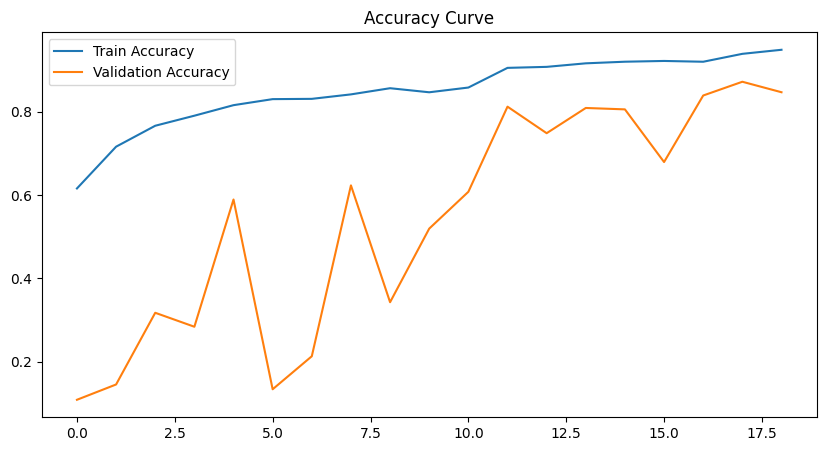

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    train_accs,
    label="Train Accuracy"
)

plt.plot(
    val_accs,
    label="Validation Accuracy"
)

plt.legend()
plt.title("Accuracy Curve")
plt.savefig("accuracy_curve_kaggle.png", dpi=300, bbox_inches="tight")
plt.show()

# eval

In [20]:
y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(
            outputs,
            1
        )

        y_true.extend(
            labels.numpy()
        )

        y_pred.extend(
            preds.cpu().numpy()
        )

acc = accuracy_score(
    y_true,
    y_pred
)

prec = precision_score(
    y_true,
    y_pred
)

rec = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")

Accuracy  : 0.9240
Precision : 0.9727
Recall    : 0.9482
F1-Score  : 0.9603


# Classification Report

In [21]:
print(
    classification_report(
        y_true,
        y_pred,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.0628    0.1154    0.0813       520
           1     0.9727    0.9482    0.9603     17313

    accuracy                         0.9240     17833
   macro avg     0.5178    0.5318    0.5208     17833
weighted avg     0.9462    0.9240    0.9347     17833



In [22]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate report dalam bentuk dictionary
report = classification_report(
    y_true,
    y_pred,
    digits=4,
    output_dict=True
)

# Convert ke DataFrame
report_df = pd.DataFrame(report).transpose()

# Simpan ke CSV
report_df.to_csv(
    "/kaggle/working/classification_report.csv"
)

print("Classification report saved!")

print(report_df)

Classification report saved!
              precision    recall  f1-score       support
0              0.062762  0.115385  0.081301    520.000000
1              0.972744  0.948247  0.960339  17313.000000
accuracy       0.923961  0.923961  0.923961      0.923961
macro avg      0.517753  0.531816  0.520820  17833.000000
weighted avg   0.946209  0.923961  0.934707  17833.000000


# Confusion Matrix

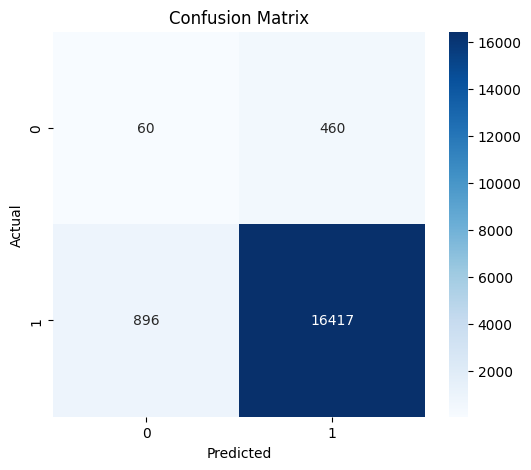

In [23]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

# ROC Curve

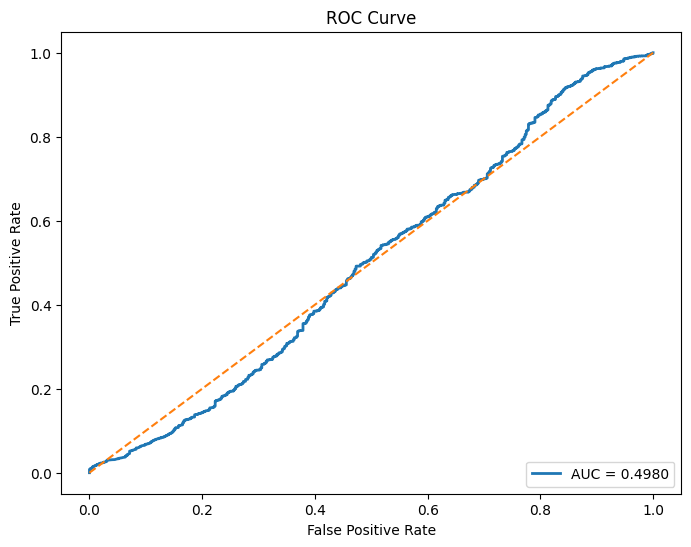

AUC Score: 0.4980


In [24]:
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = F.softmax(outputs, dim=1)

        all_probs.extend(
            probs[:,1].cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probs
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    lw=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"AUC Score: {roc_auc:.4f}")

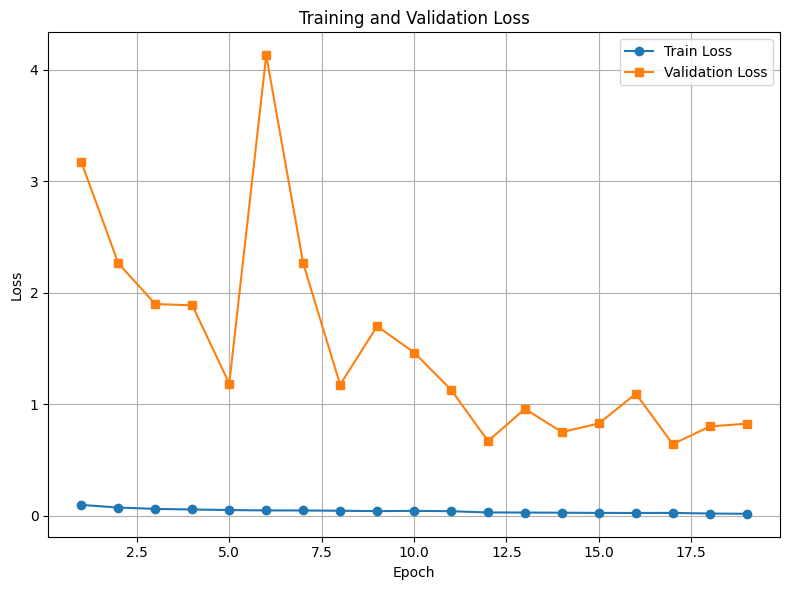

Loss curve saved as loss_curve.png


In [25]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8,6))

plt.plot(
    epochs,
    train_losses,
    marker='o',
    label='Train Loss'
)

plt.plot(
    epochs,
    val_losses,
    marker='s',
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    '/kaggle/working/loss_curve.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Loss curve saved as loss_curve.png")

In [26]:
import os

print(os.listdir("/kaggle/working"))

['confusion_matrix.png', 'loss_curve.png', 'best_vit_daisee.pth', 'roc_curve.png', '.virtual_documents', 'classification_report.csv', 'accuracy_curve_kaggle.png']


In [27]:
!ls -lh /kaggle/working

total 84M
-rw-r--r-- 1 root root 134K Jul 11 05:16 accuracy_curve_kaggle.png
-rw-r--r-- 1 root root  83M Jul 11 04:46 best_vit_daisee.pth
-rw-r--r-- 1 root root  408 Jul 11 05:17 classification_report.csv
-rw-r--r-- 1 root root  70K Jul 11 05:17 confusion_matrix.png
-rw-r--r-- 1 root root 125K Jul 11 05:18 loss_curve.png
-rw-r--r-- 1 root root 125K Jul 11 05:18 roc_curve.png


# no touch

In [28]:
from collections import Counter

print(Counter(train_dataset.targets))
print(Counter(val_dataset.targets))
print(Counter(test_dataset.targets))

Counter({1: 52087, 0: 1480})
Counter({1: 13249, 0: 1037})
Counter({1: 17313, 0: 520})


In [29]:
for name, ds in [
    ("Train", train_dataset),
    ("Validation", val_dataset),
    ("Test", test_dataset)
]:
    counter = Counter(ds.targets)
    print(name)
    print(counter)

Train
Counter({1: 52087, 0: 1480})
Validation
Counter({1: 13249, 0: 1037})
Test
Counter({1: 17313, 0: 520})
